In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv("../data/DataCoSupplyChainDataset.csv",encoding='latin1')

In [3]:
print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")

Rows: 180519
Columns: 53


In [4]:
df.head()

,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,...,Order Zipcode,Product Card Id,Product Category Id,Product Description,Product Image,Product Name,Product Price,Product Status,shipping date (DateOrders),Shipping Mode
0,DEBIT,3,4,91.250000,314.640015,Advance shipping,0,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,2/3/2018 22:56,Standard Class
1,TRANSFER,5,4,-249.089996,311.359985,Late delivery,1,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/18/2018 12:27,Standard Class
2,CASH,4,4,-247.779999,309.720001,Shipping on time,0,73,Sporting Goods,San Jose,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/17/2018 12:06,Standard Class
3,DEBIT,3,4,22.860001,304.809998,Advance shipping,0,73,Sporting Goods,Los Angeles,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/16/2018 11:45,Standard Class
4,PAYMENT,2,4,134.210007,298.250000,Advance shipping,0,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/15/2018 11:24,Standard Class


In [5]:
df.sample(5)

,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,...,Order Zipcode,Product Card Id,Product Category Id,Product Description,Product Image,Product Name,Product Price,Product Status,shipping date (DateOrders),Shipping Mode
75419,DEBIT,2,1,52.700001,169.990005,Late delivery,1,48,Water Sports,Caguas,...,85204.0,1073,48,NaN,http://images.acmesports.sports/Pelican+Sunstr...,Pelican Sunstream 100 Kayak,199.990005,0,7/27/2016 16:11,First Class
58746,PAYMENT,2,1,14.690000,129.990005,Late delivery,1,18,Men's Footwear,Caguas,...,NaN,403,18,NaN,http://images.acmesports.sports/Nike+Men%27s+C...,Nike Men's CJ Elite 2 TD Football Cleat,129.990005,0,10/27/2016 14:18,First Class
108699,PAYMENT,4,4,30.400000,112.599998,Shipping on time,0,37,Electronics,Sun Valley,...,NaN,828,37,NaN,http://images.acmesports.sports/Bridgestone+e6...,Bridgestone e6 Straight Distance NFL San Dieg,31.990000,0,3/9/2015 14:27,Standard Class
160984,TRANSFER,5,4,19.959999,76.779999,Late delivery,1,29,Shop By Sport,Caguas,...,NaN,627,29,NaN,http://images.acmesports.sports/Under+Armour+G...,Under Armour Girls' Toddler Spine Surge Runni,39.990002,0,9/25/2016 9:37,Standard Class
130713,PAYMENT,3,2,7.420000,98.959999,Late delivery,1,46,Indoor/Outdoor Games,Caguas,...,29203.0,1014,46,NaN,http://images.acmesports.sports/O%27Brien+Men%...,O'Brien Men's Neoprene Life Vest,49.980000,0,4/16/2016 7:24,Second Class


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 180519 entries, 0 to 180518
Data columns (total 53 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   Type                           180519 non-null  object 
 1   Days for shipping (real)       180519 non-null  int64  
 2   Days for shipment (scheduled)  180519 non-null  int64  
 3   Benefit per order              180519 non-null  float64
 4   Sales per customer             180519 non-null  float64
 5   Delivery Status                180519 non-null  object 
 6   Late_delivery_risk             180519 non-null  int64  
 7   Category Id                    180519 non-null  int64  
 8   Category Name                  180519 non-null  object 
 9   Customer City                  180519 non-null  object 
 10  Customer Country               180519 non-null  object 
 11  Customer Email                 180519 non-null  object 
 12  Customer Fname                

In [7]:
dtype_df = pd.DataFrame({
    "Column": df.columns,
    "Datatype": df.dtypes.values
})

dtype_df

,Column,Datatype
0,Type,object
1,Days for shipping (real),int64
2,Days for shipment (scheduled),int64
3,Benefit per order,float64
4,Sales per customer,float64
5,Delivery Status,object
6,Late_delivery_risk,int64
7,Category Id,int64
8,Category Name,object
9,Customer City,object


In [8]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Days for shipping (real),180519.0,3.497654,1.623722,0.000000,2.000000,3.000000,5.000000,6.000000
Days for shipment (scheduled),180519.0,2.931847,1.374449,0.000000,2.000000,4.000000,4.000000,4.000000
Benefit per order,180519.0,21.974989,104.433526,-4274.979980,7.000000,31.520000,64.800003,911.799988
Sales per customer,180519.0,183.107609,120.043670,7.490000,104.379997,163.990005,247.399994,1939.989990
Late_delivery_risk,180519.0,0.548291,0.497664,0.000000,0.000000,1.000000,1.000000,1.000000
Category Id,180519.0,31.851451,15.640064,2.000000,18.000000,29.000000,45.000000,76.000000
Customer Id,180519.0,6691.379495,4162.918106,1.000000,3258.500000,6457.000000,9779.000000,20757.000000
Customer Zipcode,180516.0,35921.126914,37542.461122,603.000000,725.000000,19380.000000,78207.000000,99205.000000
Department Id,180519.0,5.443460,1.629246,2.000000,4.000000,5.000000,7.000000,12.000000
Latitude,180519.0,29.719955,9.813646,-33.937553,18.265432,33.144863,39.279617,48.781933


In [9]:
df.describe(include='object').T

,count,unique,top,freq
Type,180519,4,DEBIT,69295
Delivery Status,180519,4,Late delivery,98977
Category Name,180519,50,Cleats,24551
Customer City,180519,563,Caguas,66770
Customer Country,180519,2,EE. UU.,111146
Customer Email,180519,1,XXXXXXXXX,180519
Customer Fname,180519,782,Mary,65150
Customer Lname,180511,1109,Smith,64104
Customer Password,180519,1,XXXXXXXXX,180519
Customer Segment,180519,3,Consumer,93504


In [10]:
drop_cols = [
    'Customer Email',
    'Customer Password',
    'Customer Fname',
    'Customer Lname',
    'Customer Street',
    'Product Image'
]

In [11]:
df['order date (DateOrders)'] = pd.to_datetime(
    df['order date (DateOrders)']
)

df['shipping date (DateOrders)'] = pd.to_datetime(
    df['shipping date (DateOrders)']
)

In [12]:
df[['order date (DateOrders)',
    'shipping date (DateOrders)']].dtypes

order date (DateOrders)       datetime64[ns]
shipping date (DateOrders)    datetime64[ns]
dtype: object

In [13]:
missing = pd.DataFrame({
    'Missing Count': df.isnull().sum(),
    'Missing %': round(df.isnull().mean()*100,2)
})

missing.sort_values(
    by='Missing %',
    ascending=False
)

,Missing Count,Missing %
Product Description,180519,100.00
Order Zipcode,155679,86.24
Days for shipment (scheduled),0,0.00
Days for shipping (real),0,0.00
Type,0,0.00
Delivery Status,0,0.00
Late_delivery_risk,0,0.00
Category Id,0,0.00
Category Name,0,0.00
Customer City,0,0.00


In [14]:
df.drop(columns=['Product Description'], inplace=True)

In [15]:
df.drop(columns=['Order Zipcode'], inplace=True)

In [16]:
df['Customer Zipcode'].nunique()

995

In [17]:
df.drop(columns=['Customer Zipcode'], inplace=True)

In [18]:
df.drop(columns=drop_cols,inplace=True)

In [19]:
df.columns

Index(['Type', 'Days for shipping (real)', 'Days for shipment (scheduled)',
       'Benefit per order', 'Sales per customer', 'Delivery Status',
       'Late_delivery_risk', 'Category Id', 'Category Name', 'Customer City',
       'Customer Country', 'Customer Id', 'Customer Segment', 'Customer State',
       'Department Id', 'Department Name', 'Latitude', 'Longitude', 'Market',
       'Order City', 'Order Country', 'Order Customer Id',
       'order date (DateOrders)', 'Order Id', 'Order Item Cardprod Id',
       'Order Item Discount', 'Order Item Discount Rate', 'Order Item Id',
       'Order Item Product Price', 'Order Item Profit Ratio',
       'Order Item Quantity', 'Sales', 'Order Item Total',
       'Order Profit Per Order', 'Order Region', 'Order State', 'Order Status',
       'Product Card Id', 'Product Category Id', 'Product Name',
       'Product Price', 'Product Status', 'shipping date (DateOrders)',
       'Shipping Mode'],
      dtype='object')

In [20]:
df.nunique().sort_values()

Product Status                        1
Late_delivery_risk                    2
Customer Country                      2
Customer Segment                      3
Delivery Status                       4
Days for shipment (scheduled)         4
Shipping Mode                         4
Type                                  4
Order Item Quantity                   5
Market                                5
Days for shipping (real)              7
Order Status                          9
Department Name                      11
Department Id                        11
Order Item Discount Rate             18
Order Region                         23
Customer State                       46
Category Name                        50
Category Id                          51
Product Category Id                  51
Product Price                        75
Order Item Product Price             75
Order Item Cardprod Id              118
Product Name                        118
Product Card Id                     118


In [21]:
df.drop('Product Status', axis=1, inplace=True)

In [22]:
df.drop('Order City', axis=1, inplace=True)

In [23]:
df['Order State'].value_counts().head(20)

Order State
Inglaterra                     6722
California                     4966
Isla de Francia                4580
Renania del Norte-Westfalia    3303
San Salvador                   3055
Nueva York                     2753
Distrito Federal               2559
Texas                          2446
Nueva Gales del Sur            2370
Santo Domingo                  2211
Queensland                     2186
Guatemala                      2109
São Paulo                      2031
Provenza-Alpes-Costa Azul      1842
Capital Nacional               1837
Managua                        1834
Francisco Morazán              1783
Panamá                         1631
Victoria                       1456
Pensilvania                    1406
Name: count, dtype: int64

In [24]:
(df['Customer Id']
 ==
 df['Order Customer Id']).all()

np.True_

In [25]:
df.drop('Order Customer Id', axis=1, inplace=True)

In [26]:
(df['Benefit per order']
 ==
 df['Order Profit Per Order']).all()

np.True_

In [27]:
df.drop('Benefit per order', axis=1, inplace=True)

In [28]:
df[['Order Profit Per Order',
    'Order Item Profit Ratio']].corr()

,Order Profit Per Order,Order Item Profit Ratio
Order Profit Per Order,1.000000,0.823689
Order Item Profit Ratio,0.823689,1.000000


In [29]:
df.drop('Order Item Profit Ratio', axis=1, inplace=True)

In [30]:
df.drop('Order Profit Per Order', axis=1, inplace=True)

In [31]:
df.columns

Index(['Type', 'Days for shipping (real)', 'Days for shipment (scheduled)',
       'Sales per customer', 'Delivery Status', 'Late_delivery_risk',
       'Category Id', 'Category Name', 'Customer City', 'Customer Country',
       'Customer Id', 'Customer Segment', 'Customer State', 'Department Id',
       'Department Name', 'Latitude', 'Longitude', 'Market', 'Order Country',
       'order date (DateOrders)', 'Order Id', 'Order Item Cardprod Id',
       'Order Item Discount', 'Order Item Discount Rate', 'Order Item Id',
       'Order Item Product Price', 'Order Item Quantity', 'Sales',
       'Order Item Total', 'Order Region', 'Order State', 'Order Status',
       'Product Card Id', 'Product Category Id', 'Product Name',
       'Product Price', 'shipping date (DateOrders)', 'Shipping Mode'],
      dtype='object')

In [32]:
drop_cols=['Category Id',
'Department Id',
'Product Category Id',
'Product Card Id',
'Order Item Cardprod Id',
'Order Item Id',
'Order Id']

In [33]:
df.drop(columns=drop_cols,inplace=True)

In [34]:
df.columns

Index(['Type', 'Days for shipping (real)', 'Days for shipment (scheduled)',
       'Sales per customer', 'Delivery Status', 'Late_delivery_risk',
       'Category Name', 'Customer City', 'Customer Country', 'Customer Id',
       'Customer Segment', 'Customer State', 'Department Name', 'Latitude',
       'Longitude', 'Market', 'Order Country', 'order date (DateOrders)',
       'Order Item Discount', 'Order Item Discount Rate',
       'Order Item Product Price', 'Order Item Quantity', 'Sales',
       'Order Item Total', 'Order Region', 'Order State', 'Order Status',
       'Product Name', 'Product Price', 'shipping date (DateOrders)',
       'Shipping Mode'],
      dtype='object')

## Feature engineering and dataset preparation

In [35]:
num_cols = df.select_dtypes(include=['int64','float64']).columns

skew_df = pd.DataFrame({
    'Feature': num_cols,
    'Skewness': [df[col].skew() for col in num_cols]
})

skew_df.sort_values(
    by='Skewness',
    ascending=False
)

,Feature,Skewness
13,Product Price,3.191020
9,Order Item Product Price,3.191020
7,Order Item Discount,3.039796
12,Order Item Total,2.888446
2,Sales per customer,2.888446
11,Sales,2.884249
10,Order Item Quantity,0.880252
4,Customer Id,0.488768
8,Order Item Discount Rate,0.340928
0,Days for shipping (real),0.084771


In [36]:
df['Sales_log'] = np.log1p(df['Sales'])

df['ProductPrice_log'] = np.log1p(df['Product Price'])

df['Discount_log'] = np.log1p(df['Order Item Discount'])

In [37]:
corr_target = (
    df.select_dtypes(
        include=['int64','float64']
    )
    .corr()['Late_delivery_risk']
    .sort_values(ascending=False)
)

corr_target

Late_delivery_risk               1.000000
Days for shipping (real)         0.401415
Customer Id                      0.001484
Latitude                         0.000679
Order Item Discount Rate         0.000404
Order Item Quantity             -0.000139
Order Item Discount             -0.000750
Longitude                       -0.001915
Order Item Product Price        -0.002175
Product Price                   -0.002175
ProductPrice_log                -0.002230
Sales_log                       -0.003116
Discount_log                    -0.003133
Sales                           -0.003564
Sales per customer              -0.003791
Order Item Total                -0.003791
Days for shipment (scheduled)   -0.369352
Name: Late_delivery_risk, dtype: float64

In [38]:
classification_df=df.copy()

In [39]:
classification_df.columns

Index(['Type', 'Days for shipping (real)', 'Days for shipment (scheduled)',
       'Sales per customer', 'Delivery Status', 'Late_delivery_risk',
       'Category Name', 'Customer City', 'Customer Country', 'Customer Id',
       'Customer Segment', 'Customer State', 'Department Name', 'Latitude',
       'Longitude', 'Market', 'Order Country', 'order date (DateOrders)',
       'Order Item Discount', 'Order Item Discount Rate',
       'Order Item Product Price', 'Order Item Quantity', 'Sales',
       'Order Item Total', 'Order Region', 'Order State', 'Order Status',
       'Product Name', 'Product Price', 'shipping date (DateOrders)',
       'Shipping Mode', 'Sales_log', 'ProductPrice_log', 'Discount_log'],
      dtype='object')

In [40]:
classification_df.drop(
    'Days for shipping (real)',
    axis=1,
    inplace=True
)

In [41]:
num_cols = classification_df.select_dtypes(
    include=['int64','float64']
).columns

num_cols

Index(['Days for shipment (scheduled)', 'Sales per customer',
       'Late_delivery_risk', 'Customer Id', 'Latitude', 'Longitude',
       'Order Item Discount', 'Order Item Discount Rate',
       'Order Item Product Price', 'Order Item Quantity', 'Sales',
       'Order Item Total', 'Product Price', 'Sales_log', 'ProductPrice_log',
       'Discount_log'],
      dtype='object')

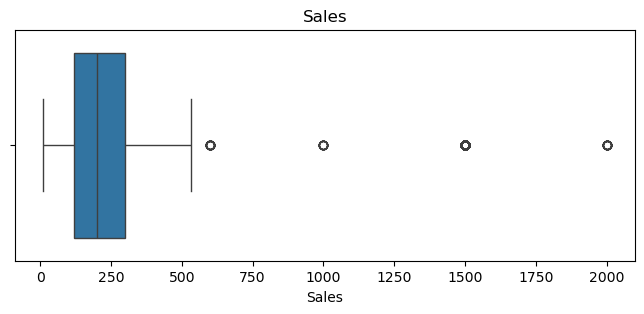

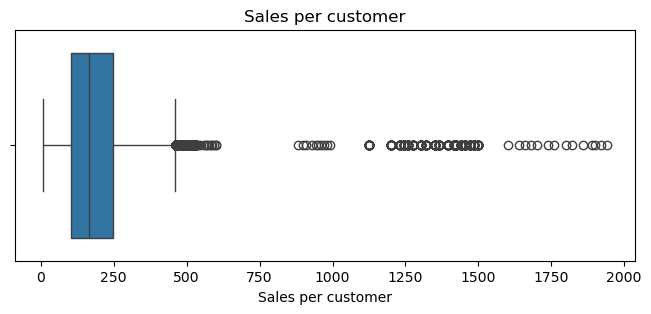

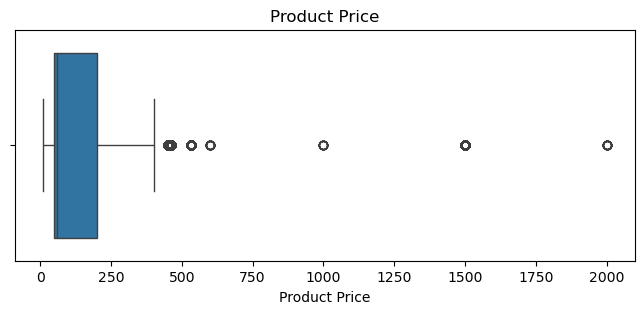

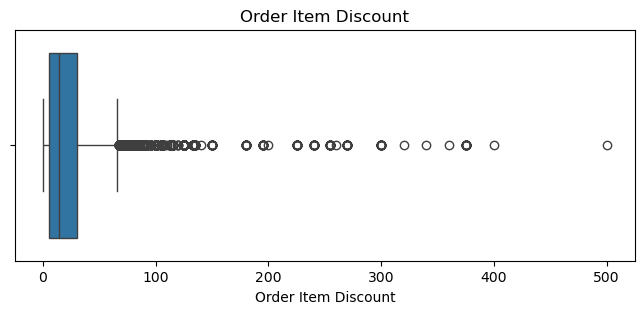

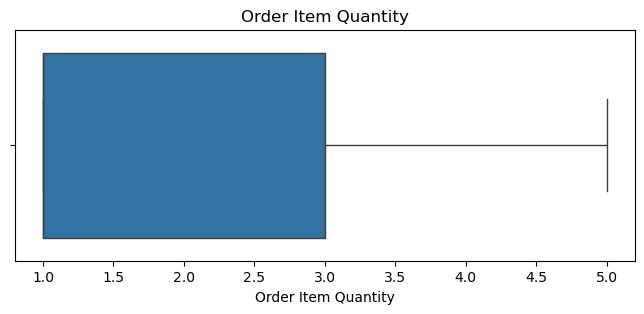

In [42]:
important_cols = [
    'Sales',
    'Sales per customer',
    'Product Price',
    'Order Item Discount',
    'Order Item Quantity'
]

for col in important_cols:
    
    plt.figure(figsize=(8,3))
    
    sns.boxplot(
        x=classification_df[col]
    )
    
    plt.title(col)
    
    plt.show()

In [43]:
classification_df.columns

Index(['Type', 'Days for shipment (scheduled)', 'Sales per customer',
       'Delivery Status', 'Late_delivery_risk', 'Category Name',
       'Customer City', 'Customer Country', 'Customer Id', 'Customer Segment',
       'Customer State', 'Department Name', 'Latitude', 'Longitude', 'Market',
       'Order Country', 'order date (DateOrders)', 'Order Item Discount',
       'Order Item Discount Rate', 'Order Item Product Price',
       'Order Item Quantity', 'Sales', 'Order Item Total', 'Order Region',
       'Order State', 'Order Status', 'Product Name', 'Product Price',
       'shipping date (DateOrders)', 'Shipping Mode', 'Sales_log',
       'ProductPrice_log', 'Discount_log'],
      dtype='object')

In [45]:
classification_df.drop(
    columns=[
        'Delivery Status',
        'shipping date (DateOrders)'
    ],
    inplace=True
)

In [46]:
classification_df['order date (DateOrders)'] = pd.to_datetime(
    classification_df['order date (DateOrders)']
)

In [47]:
classification_df['Order_Month'] = (
    classification_df['order date (DateOrders)']
    .dt.month
)

classification_df['Order_Quarter'] = (
    classification_df['order date (DateOrders)']
    .dt.quarter
)

classification_df['Order_DayOfWeek'] = (
    classification_df['order date (DateOrders)']
    .dt.dayofweek
)

classification_df['Is_Weekend'] = (
    classification_df['Order_DayOfWeek'] >= 5
).astype(int)

In [48]:
classification_df['Revenue_Per_Item'] = (
    classification_df['Sales']
    /
    classification_df['Order Item Quantity']
)

In [49]:
classification_df['Discount_Per_Item'] = (
    classification_df['Order Item Discount']
    /
    classification_df['Order Item Quantity']
)

In [50]:
classification_df['Discount_to_Sales'] = (
    classification_df['Order Item Discount']
    /
    classification_df['Sales']
)

In [51]:
classification_df['Discount_to_Sales'] = (
    classification_df['Discount_to_Sales']
    .replace([np.inf,-np.inf],0)
)

In [52]:
classification_df['Customer_Total_Orders'] = (
    classification_df
    .groupby('Customer Id')['Sales']
    .transform('count')
)

In [53]:
classification_df['Customer_Total_Revenue'] = (
    classification_df
    .groupby('Customer Id')['Sales']
    .transform('sum')
)

In [54]:
classification_df['Customer_Avg_Order_Value'] = (
    classification_df
    .groupby('Customer Id')['Sales']
    .transform('mean')
)

In [55]:
classification_df.drop(
    columns=['order date (DateOrders)'],
    inplace=True
)

In [56]:
classification_df[
    'Late_delivery_risk'
].value_counts(normalize=True)*100

Late_delivery_risk
1    54.829132
0    45.170868
Name: proportion, dtype: float64

In [57]:
classification_df.to_csv(
    "classification_ready.csv",
    index=False
)

In [62]:
classification_df['Shipping Mode'].value_counts()

Shipping Mode
Standard Class    107752
Second Class       35216
First Class        27814
Same Day            9737
Name: count, dtype: int64